# DCS602 – Homework 2: Information Visualization
## Complete Solution Notebook
### University of Buea – Department of Computer Science

**Dataset:** CIA World Factbook (149 countries, 29 attributes)  
**Library:** Bokeh (interactive visualizations)

---


## 0. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import os, re

import bokeh
print('pandas', pd.__version__)
print('bokeh ', bokeh.__version__)


pandas 2.2.3
bokeh  3.6.0


---
## Exploratory Data Analysis & Data Preparation

Before any visualization we must:
1. **Understand** the dataset – shape, types, missing values.
2. **Clean** – convert currency/comma strings to floats.
3. **Save** `factbook_clean.csv` for all task files to load.


In [4]:
RAW_PATH = "./factbook - factbook.csv"
df_raw = pd.read_csv(RAW_PATH)
print(f"Shape: {df_raw.shape}")
print("Columns:", list(df_raw.columns))


Shape: (149, 29)
Columns: ['Country', 'Area', 'Birth rate', 'Current account balance', 'Death rate', 'Electricity consumption', 'Electricity production', 'Exports', 'GDP', 'GDP per capita', 'GDP real growth rate', 'Highways', 'Imports', 'Industrial production growth rate', 'Infant mortality rate', 'Inflation rate', 'Internet users', 'Investment', 'Labor force', 'Life expectancy at birth', 'Military expenditures', 'Natural gas consumption', 'Oil consumption', 'Population', 'Public debt', 'Railways', 'Reserves of foreign exchange & gold', 'Total fertility rate', 'Unemployment rate']


In [5]:
df_raw.head()

,Country,Area,Birth rate,Current account balance,Death rate,Electricity consumption,Electricity production,Exports,GDP,GDP per capita,...,Life expectancy at birth,Military expenditures,Natural gas consumption,Oil consumption,Population,Public debt,Railways,Reserves of foreign exchange & gold,Total fertility rate,Unemployment rate
0,Japan,"377,835",9.47,"$170,200,000,000.00",8.95,"971,000,000,000","1,044,000,000,000.00","$538,800,000,000.00","$3,745,000,000,000.00","$29,400.00",...,81.15,1.0,"80,420,000,000.00","5,290,000","127,417,244",164.3,23705.0,"664,600,000,000.00",1.39,4.7
1,Germany,"357,021",8.33,"$73,590,000,000.00",10.55,"519,500,000,000","560,000,000,000.00","$893,300,000,000.00","$2,362,000,000,000.00","$28,700.00",...,78.65,1.5,"99,550,000,000.00","2,891,000","82,431,390",65.8,46039.0,"96,840,000,000.00",1.39,10.6
2,Saudi Arabia,"1,960,582",29.56,"$51,500,000,000.00",2.62,"128,500,000,000","138,200,000,000.00","$113,000,000,000.00","$310,200,000,000.00","$12,000.00",...,75.46,10.0,"56,400,000,000.00","1,550,000","26,417,599",75.0,1392.0,"23,620,000,000.00",4.05,25.0
3,Russia,"17,075,200",9.80,"$46,040,000,000.00",14.52,"894,300,000,000","915,000,000,000.00","$162,500,000,000.00","$1,408,000,000,000.00","$9,800.00",...,67.10,NaN,"405,800,000,000.00","2,310,000","143,420,309",28.2,87157.0,"124,500,000,000.00",1.27,8.3
4,Switzerland,"41,290",9.77,"$40,950,000,000.00",8.48,"54,530,000,000","63,470,000,000.00","$130,700,000,000.00","$251,900,000,000.00","$33,800.00",...,80.39,1.0,"3,093,000,000.00","290,400","7,489,370",57.2,4533.0,"69,580,000,000.00",1.42,3.4


In [6]:
# Data types (notice many numeric-looking columns are 'object'/string)
df_raw.dtypes


Country                                 object
Area                                    object
Birth rate                             float64
Current account balance                 object
Death rate                             float64
Electricity consumption                 object
Electricity production                  object
Exports                                 object
GDP                                     object
GDP per capita                          object
GDP real growth rate                   float64
Highways                                object
Imports                                 object
Industrial production growth rate      float64
Infant mortality rate                  float64
Inflation rate                         float64
Internet users                          object
Investment                             float64
Labor force                             object
Life expectancy at birth               float64
Military expenditures                  float64
Natural gas c

In [7]:
# Missing values before cleaning
df_raw.isnull().sum()[df_raw.isnull().sum() > 0]


Industrial production growth rate      15
Investment                              5
Labor force                             9
Military expenditures                   5
Natural gas consumption                47
Public debt                            41
Railways                               27
Reserves of foreign exchange & gold     2
Unemployment rate                      22
dtype: int64

In [8]:
# Numeric stats for already-numeric columns
df_raw.select_dtypes(include=[np.number]).describe().round(2)


,Birth rate,Death rate,GDP real growth rate,Industrial production growth rate,Infant mortality rate,Inflation rate,Investment,Life expectancy at birth,Military expenditures,Public debt,Railways,Total fertility rate,Unemployment rate
count,149.00,149.00,149.00,134.00,149.00,149.00,144.00,149.00,144.00,108.00,122.00,149.00,127.00
mean,21.89,9.86,5.30,6.25,36.46,6.99,21.75,66.93,2.67,55.90,9295.16,2.88,14.47
std,11.00,5.09,5.71,5.48,33.24,12.54,8.12,12.32,2.45,36.95,24485.42,1.52,12.78
min,7.23,2.42,-8.20,-7.80,2.29,-0.30,8.00,33.87,0.20,2.10,6.00,0.91,0.60
25%,12.03,6.26,3.00,3.00,8.57,2.30,17.18,61.39,1.30,31.48,894.75,1.71,6.10
50%,18.78,8.68,4.80,5.00,24.52,4.10,19.85,71.55,1.90,50.75,2718.50,2.44,10.40
75%,29.74,11.81,6.10,8.38,61.50,7.60,24.55,76.14,3.10,69.68,5769.00,3.87,18.00
max,47.39,29.36,52.30,30.00,191.19,133.00,65.10,81.62,14.60,228.30,228464.00,6.74,70.00


In [9]:
def clean_numeric(series):
    """Strip $, commas, trailing text; return float Series."""
    if series.dtype in [np.float64, np.int64]:
        return series.astype(float)
    s = series.astype(str).str.strip()
    s = s.str.replace(r'[\$,]', '', regex=True)
    s = s.str.replace(r'\s.*', '', regex=True)
    return pd.to_numeric(s, errors='coerce')

CLEAN_COLS = [
    "Area", "Current account balance", "Electricity consumption",
    "Electricity production", "Exports", "GDP", "GDP per capita",
    "Highways", "Imports", "Internet users", "Labor force",
    "Natural gas consumption", "Oil consumption", "Population",
    "Reserves of foreign exchange & gold"
]

df = df_raw.copy()
for col in CLEAN_COLS:
    if col in df.columns:
        df[col] = clean_numeric(df[col])

print("Types after cleaning:")
df.dtypes


Types after cleaning:


Country                                 object
Area                                     int64
Birth rate                             float64
Current account balance                float64
Death rate                             float64
Electricity consumption                  int64
Electricity production                 float64
Exports                                float64
GDP                                    float64
GDP per capita                         float64
GDP real growth rate                   float64
Highways                                 int64
Imports                                float64
Industrial production growth rate      float64
Infant mortality rate                  float64
Inflation rate                         float64
Internet users                         float64
Investment                             float64
Labor force                            float64
Life expectancy at birth               float64
Military expenditures                  float64
Natural gas c

In [10]:
# Save clean file (all task scripts load this)
df.to_csv("factbook_clean.csv", index=False)
print("Saved factbook_clean.csv")
df[["Country","GDP per capita","Life expectancy at birth",
    "Population","Birth rate"]].head(10)


Saved factbook_clean.csv


,Country,GDP per capita,Life expectancy at birth,Population,Birth rate
0,Japan,29400.0,81.15,127417244,9.47
1,Germany,28700.0,78.65,82431390,8.33
2,Saudi Arabia,12000.0,75.46,26417599,29.56
3,Russia,9800.0,67.10,143420309,9.80
4,Switzerland,33800.0,80.39,7489370,9.77
5,Norway,40000.0,79.40,4593041,11.67
6,China,5600.0,72.27,1306313812,13.14
7,Canada,31500.0,80.10,32805041,10.84
8,Korea South,19200.0,75.82,48422644,10.08
9,Sweden,28400.0,80.40,9001774,10.36


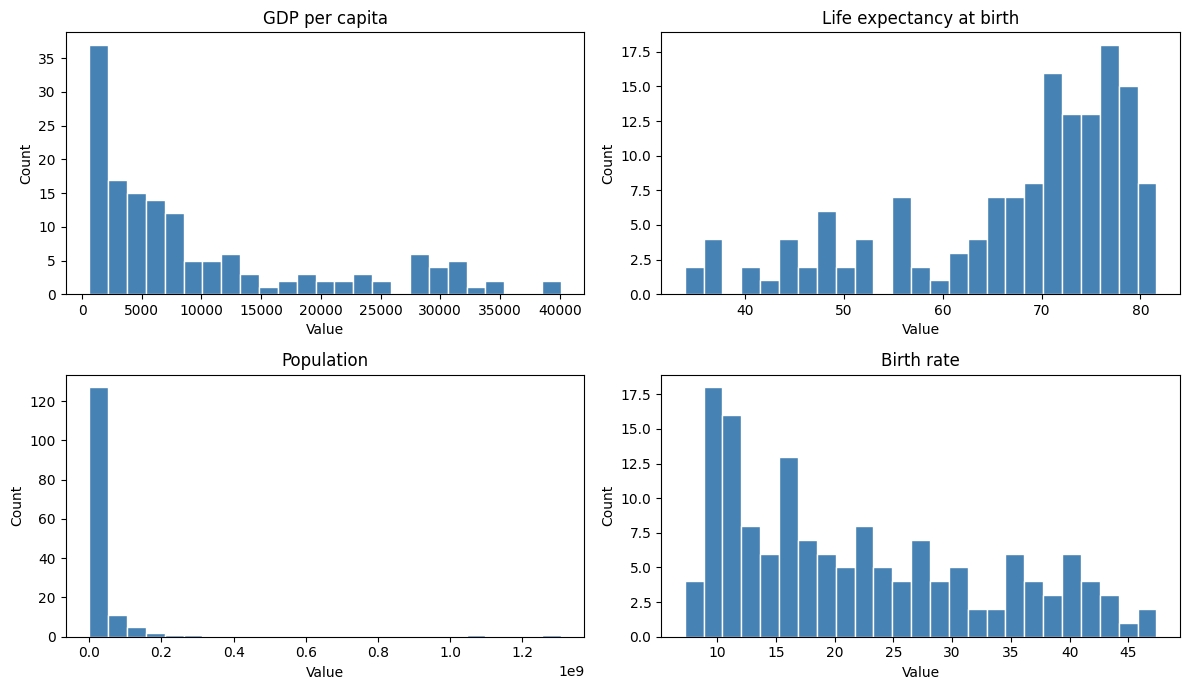

In [11]:
# Quick distribution check for the 4 key Task-1 variables
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
key_cols = ["GDP per capita", "Life expectancy at birth",
            "Population", "Birth rate"]
for ax, col in zip(axes.flat, key_cols):
    ax.hist(df[col].dropna(), bins=25, edgecolor='white', color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


---
## Task 1 – Basic Bubble Chart (`p2_bubbles.py`)

A bubble chart encodes **four variables** simultaneously:

| Visual channel | Variable |
|---|---|
| x position | GDP per capita |
| y position | Life expectancy at birth |
| circle **area** (radius) | Population |
| circle **color** | Birth rate |

### Design rationale
- **Radius** scaled as `sqrt(Population)` so *area* is proportional to population (not radius).
- **Color palette** `YlOrRd` (Yellow→Red): low birth rate = pale/yellow, high = red.
- `ColorBar` on the right explains the color encoding.
- `HoverTool` gives country details on mouse-over.

> Run `python p2_bubbles.py` → opens `p2_bubbles.html` in your browser.


In [13]:
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import (ColorBar, HoverTool, ColumnDataSource,
                          LinearColorMapper, BasicTicker)
from bokeh.palettes import YlOrRd9

output_notebook()

df = pd.read_csv("factbook_clean.csv")
df = df.dropna(subset=["GDP per capita","Life expectancy at birth",
                        "Population","Birth rate"])

# Scale radii: area proportional to population
pop_sqrt = np.sqrt(df["Population"].values)
radii = 6 + (50 - 6) * (pop_sqrt - pop_sqrt.min()) / (pop_sqrt.max() - pop_sqrt.min())

source = ColumnDataSource(dict(
    x          = df["GDP per capita"].values,
    y          = df["Life expectancy at birth"].values,
    radii      = radii,
    color_val  = df["Birth rate"].values,
    country    = df["Country"].values,
    population = df["Population"].values,
    birth_rate = df["Birth rate"].values,
))

mapper = LinearColorMapper(
    palette = list(reversed(YlOrRd9)),
    low     = df["Birth rate"].min(),
    high    = df["Birth rate"].max(),
)

p = figure(width=860, height=520,
           title="GDP per Capita vs Life Expectancy "
                 "(bubble size = Population, color = Birth rate)",
           x_axis_label="GDP per Capita (USD)",
           y_axis_label="Life Expectancy at Birth (years)",
           tools="pan,wheel_zoom,box_zoom,reset,save")

p.circle(x="x", y="y",
         radius="radii", radius_units="screen",
         fill_color={"field":"color_val","transform":mapper},
         fill_alpha=0.7, line_color="white", line_width=0.5,
         source=source)

p.add_tools(HoverTool(tooltips=[
    ("Country",        "@country"),
    ("GDP per capita", "@x{$0,0}"),
    ("Life exp",       "@y{0.0} yrs"),
    ("Population",     "@population{0,0}"),
    ("Birth rate",     "@birth_rate{0.00}"),
]))

p.add_layout(ColorBar(color_mapper=mapper,
                       ticker=BasicTicker(desired_num_ticks=8),
                       title="Birth rate", location=(0,0)), "right")
p.xaxis.formatter.use_scientific = False
show(p)


Loading BokehJS ...

---
## Task 2 – Interactive Widgets (`p2_widgets.py`)

Widgets let the user **choose at runtime** which attribute maps to each channel.

### Widgets used
| Widget | Bokeh class | What it controls |
|---|---|---|
| 4 drop-downs | `Select` | x axis, y axis, radius attribute, color attribute |
| 1 slider | `Slider` | Global radius scale multiplier |

### Callback pattern
```python
def update(attr, old, new):
    src.data = make_source(sel_x.value, sel_y.value,
                           sel_r.value, sel_c.value,
                           slider.value)
    p.xaxis.axis_label = sel_x.value
    ...

for w in [sel_x, sel_y, sel_r, sel_c, slider]:
    w.on_change("value", update)
```

Setting `src.data` triggers an immediate browser re-render.

> **Must run as a Bokeh server app:**  
> `bokeh serve --show p2_widgets.py`


In [ ]:
# Read and display p2_widgets.py source
with open("p2_widgets.py") as f:
    src_text = f.read()
print(src_text)


---
## Task 3 – Linked Brushing (`p2_brushing.py`)

Four bubble charts share **one `ColumnDataSource`**.  
Bokeh's selection model propagates across all renderers that reference it.

### Architecture diagram
```
         ┌───────────────────────────────┐
         │    ColumnDataSource (shared)  │
         └──┬──────┬──────┬──────┬──────┘
            │      │      │      │
         Chart1  Chart2  Chart3  Chart4
```

### Selection appearance
```python
p.circle(
    ...
    selection_fill_alpha   = 1.0,
    selection_line_color   = "black",
    selection_line_width   = 1.5,
    nonselection_fill_alpha= 0.15,   # fade unselected bubbles
    nonselection_line_alpha= 0.1,
    source = source,                 # SAME object in all 4 charts
)
```

The **Box Select** tool lets the user draw a rectangle;  
Bokeh marks those rows as selected in the shared source → all charts update.

> `bokeh serve --show p2_brushing.py`


In [ ]:
with open("p2_brushing.py") as f:
    print(f.read())


---
## Task 4 – Details on Demand (`p2_tooltip.py`)

Extends Task 3 with:
1. **Rich hover tooltip** – all numeric attributes shown for hovered country.
2. **Cross-chart hover highlight** via `CustomJS` (browser-side JavaScript).

### Why CustomJS instead of Python callback for hover?
Hover fires on every mouse move. A Python callback would require a network
round-trip to the Bokeh server on every pixel, causing visible lag.  
A `CustomJS` callback runs **in the browser instantly**.

### Highlight callback
```javascript
// Runs in the browser when any circle is hovered
const idx = cb_data.index.indices;
for (let r of renderers) {
    r.data_source.selected.indices = idx.slice();
}
```

### Tooltip for all columns
```python
def all_tooltips(numeric_cols):
    tips = [("Country", "@country")]
    for col in numeric_cols:
        tips.append((col, f"@{{{col}}}{{0,0.00}}"))
    return tips
```

> `bokeh serve --show p2_tooltip.py`


In [ ]:
with open("p2_tooltip.py") as f:
    print(f.read())


---
## Information Visualization Concepts – Exam Preparation

### 1. Visual Encoding Channels (Bertin → Cleveland & McGill hierarchy)
Humans read visual channels with different accuracy:
1. **Position on a common scale** (x/y axes) – most accurate
2. **Length / size**
3. Angle
4. Area  ← bubble size lives here
5. **Color hue/saturation** – least accurate for quantities

A bubble chart cleverly stacks 4 channels: x, y, area, color.

---
### 2. Why sqrt(Population) for radius?
If radius ∝ population, then area ∝ population².  
China would look ~100× bigger than it should relative to a country with
1/10th the population.  
Setting `radius ∝ sqrt(population)` keeps **area ∝ population** – perceptually correct.

---
### 3. Shneiderman's Visual Information Seeking Mantra
> **Overview first → Zoom & filter → Details on demand**

| Stage | Our implementation |
|---|---|
| Overview | Bubble chart showing all 149 countries |
| Zoom & filter | Pan/zoom tools, dropdown to remap axes |
| Details on demand | Hover tooltip with all attributes |

---
### 4. Linked Views & Brushing
**Linked views:** multiple charts showing the same dataset from different perspectives.  
**Brushing:** selecting a subset in one view highlights it in all others.

Bokeh implements this through the shared `ColumnDataSource`:
- Every chart renders from the same data object.
- `source.selected.indices` is shared state → updating it refreshes all charts.

---
### 5. ColumnDataSource – Bokeh's data model
```
Python dict  →  ColumnDataSource  →  BokehJS mirror in browser
                      ↑                        ↑
               Python callbacks          CustomJS callbacks
```
The source is the single source of truth. Updating `source.data` from
Python (server) or modifying `selected.indices` from JS (client) both
cause immediate re-renders.

---
### 6. Interaction Taxonomy (Ben Shneiderman, 1996)
| Interaction type | Example in our app |
|---|---|
| Select | Box Select brushing |
| Explore | Pan / zoom |
| Reconfigure | Change axis mapping via dropdown |
| Encode | Change color attribute |
| Abstract/Elaborate | Hover tooltip = elaborate |
| Filter | Slider scales bubbles |
| Connect | Linked brushing = connect views |

---
### 7. Color Design
- **Sequential palette** (YlOrRd): one hue family, varying lightness.
  Good for ordered data where 0 = natural baseline.
- **Diverging palette** (RdBu): two hues from a neutral midpoint.
  Good for data centered around zero (e.g., GDP growth).
- **Categorical palette** (Category10): distinct hues for nominal groups.

---
### 8. Scalability Issues
| Problem | Symptom | Remedy |
|---|---|---|
| Overplotting | Bubbles overlap, data hidden | Reduce alpha, jitter, aggregate |
| Too many tooltip rows | Tooltip too tall | Show only key attributes |
| Slow Python hover callbacks | Lag on mouse move | Use CustomJS (client-side) |
| Attribute overload | Too many dropdowns | Group attributes logically |


---
## How to Run All Files

| File | Command | Notes |
|---|---|---|
| `eda_and_preparation.py` | `python eda_and_preparation.py` | Generates `factbook_clean.csv` |
| `p2_bubbles.py` | `python p2_bubbles.py` | Opens `p2_bubbles.html` |
| `p2_widgets.py` | `bokeh serve --show p2_widgets.py` | Interactive server app |
| `p2_brushing.py` | `bokeh serve --show p2_brushing.py` | Interactive server app |
| `p2_tooltip.py` | `bokeh serve --show p2_tooltip.py` | Interactive server app |

**Install dependencies:**
```bash
pip install bokeh pandas numpy
```
